In [1]:
from ase import atoms
import numpy as np
from ase.calculators.lj import LennardJones
from ase.optimize import BFGS
from ase.visualize import view
from rdkit.Chem import rdMolAlign
from rdkit import Chem
import matplotlib.pyplot as plt
from tblite.ase import TBLite
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit.Chem.rdMolTransforms import GetDihedralDeg
import math
import pandas as pd

Molecule setup

In [2]:
input = "CCCC(=O)OCCCC"

mol = AllChem.MolFromSmiles(input)
mol = AllChem.AddHs(mol)

2. conformer generation
3. Geometry optimization
4. save optimized structures
- initialize report

In [3]:
n_rotatable = Descriptors.NumRotatableBonds(mol)
NUM_CONFS = 25 # (25 for testing so it doesn't take years)
#NUM_CONFS = min(25 + 15 * n_rotatable, 300) # 300 max conformers, but scales based on molecule complexity

F_MAX = 0.05
ENERGY_THRESHOLD = 10.0 # kcal/mol    change to filtering conformers based on threshold determined by boltzman distribution, ex. remove conformer if population < threshold

RMSD_THRESHOLD = 0.75 # in angstroms, upper threshold for how similar two conformers must be to be considered duplicates
# can be ambiguous/tuned based on molecule size/complexity...maybe implement same algorithm as NUM_CONFS to determine this value based on size + complexity?



params = AllChem.ETKDGv3()
params.randomSeed = 42

AllChem.EmbedMultipleConfs(
    mol,
    numConfs=NUM_CONFS,
    params=params
)


# find proper optimization value




results = []

for conf in mol.GetConformers():
    conf_id = conf.GetId()

    # construct ASE atoms object from conformer
    positions = conf.GetPositions()
    symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
    atom = atoms.Atoms(symbols=symbols, positions=positions)

    atom.calc = TBLite(method="GFN2-xTB")
    opt = BFGS(atom)
    opt.run(fmax=F_MAX)

# update rdkit conformer positions with optimized positions from ASE
    optimized_positions = atom.get_positions()
    for idx in range(mol.GetNumAtoms()):
        x, y, z = optimized_positions[idx]
        conf.SetAtomPosition(idx, (float(x), float(y), float(z)))


    # create list of "results" dict, contains each conformer profile
    results.append({
        "id": conf_id,
        "energy": atom.get_potential_energy() * 23.0605, # stores energy in eV --> convert to kcal/mol
        "conformer": conf, # rdkit conformer object
        "atoms": atom.copy() # ASE atoms object for each conformer
    })

results.sort(key=lambda x: x["energy"])
print(f"Number of prefiltered conformers: {len(results)}")

------------------------------------------------------------
  cycle        total energy    energy error   density error
------------------------------------------------------------
      1     -33.17276041573  -3.3536234E+01   1.5393132E-01
      2     -33.38591969295  -2.1315928E-01   6.3701686E-02
      3     -33.40334460204  -1.7424909E-02   3.8081031E-02
      4     -33.40846437669  -5.1197747E-03   1.2099083E-02
      5     -33.41026056331  -1.7961866E-03   4.0603196E-03
      6     -33.41033695125  -7.6387938E-05   1.7585658E-03
      7     -33.41036772680  -3.0775546E-05   5.0224653E-04
      8     -33.41036857376  -8.4696570E-07   1.2943752E-04
      9     -33.41036864173  -6.7962795E-08   4.9262069E-05
     10     -33.41036864586  -4.1301220E-09   1.5914426E-05
------------------------------------------------------------

 total:                                   0.335 sec
      Step     Time          Energy          fmax
BFGS:    0 20:59:52     -909.142438        4.205314
--

5. Energy filtering + Boltzman distribution
- remove all optimized conformers 5 kcal/mol above minimum value, not likely to be physically formed


Boltzman distribution (how commonly each conformer is occupied physically)

$$P_i = \frac{e^{-\Delta E_i / (RT)}}{\sum_{j} e^{-\Delta E_j / (RT)}}$$

- use relative energies between conformers, not absolute ones like outputed from xTB

In [4]:
min_energy = results[0]["energy"]

# Boltzman population analysis on unfiltered conformers. filtering is after
TEMPERATURE = 298.15 # in kelvin, can be adjusted based on needs, but this plays a role in boltzman distribution calculations
R = 0.0019872041  # in kcal/(mol*K)
for result in results:
    result['relative_energy'] = result['energy'] - min_energy

    delta_e = result['relative_energy']
    boltz_factor = math.exp(-delta_e / (R * TEMPERATURE))

    result['boltzmann_factor'] = boltz_factor

partition_function = sum(result["boltzmann_factor"] for result in results)

for result in results:
    result['population'] = result['boltzmann_factor'] / partition_function


for result in results:
    print(
        f"Conf {result['id']:>2} | "
        f"E = {result['energy']:.2f} kcal/mol | "
        f"dE = {result['relative_energy']:.2f} | "
        f"Pop = {result['population']*100:.2f}%"
    )



conformer_list_filtered = []

# filter based on population
for result in results:
    if result["population"] >= 0.01: # filter conformers with population less than 1%
        conformer_list_filtered.append(result)
# filtering part below



for result in conformer_list_filtered:
    if result["energy"] - min_energy >= ENERGY_THRESHOLD:
        conformer_list_filtered.remove(result)

conformer_list_filtered.sort(key=lambda x: x["energy"])

print(f"Number of filtered conformers: {len(conformer_list_filtered)}")

Conf 20 | E = -20987.13 kcal/mol | dE = 0.00 | Pop = 10.88%
Conf  1 | E = -20987.05 kcal/mol | dE = 0.08 | Pop = 9.43%
Conf 10 | E = -20987.04 kcal/mol | dE = 0.09 | Pop = 9.33%
Conf 22 | E = -20986.95 kcal/mol | dE = 0.18 | Pop = 8.01%
Conf 13 | E = -20986.89 kcal/mol | dE = 0.24 | Pop = 7.22%
Conf 17 | E = -20986.85 kcal/mol | dE = 0.29 | Pop = 6.72%
Conf  3 | E = -20986.80 kcal/mol | dE = 0.33 | Pop = 6.23%
Conf  5 | E = -20986.73 kcal/mol | dE = 0.40 | Pop = 5.52%
Conf 21 | E = -20986.66 kcal/mol | dE = 0.47 | Pop = 4.92%
Conf  9 | E = -20986.58 kcal/mol | dE = 0.55 | Pop = 4.27%
Conf 16 | E = -20986.54 kcal/mol | dE = 0.60 | Pop = 3.96%
Conf  7 | E = -20986.43 kcal/mol | dE = 0.71 | Pop = 3.31%
Conf 11 | E = -20986.40 kcal/mol | dE = 0.74 | Pop = 3.13%
Conf 18 | E = -20986.40 kcal/mol | dE = 0.74 | Pop = 3.13%
Conf  4 | E = -20986.30 kcal/mol | dE = 0.84 | Pop = 2.65%
Conf 12 | E = -20986.17 kcal/mol | dE = 0.97 | Pop = 2.12%
Conf 23 | E = -20986.12 kcal/mol | dE = 1.01 | Pop = 1.

6. RMSD analysis
- pairwise comparisons of each conformer to determine similarity

In [5]:
# create dictionary with index of conformer: conformer id
index_map = {}
for idx, item in enumerate(conformer_list_filtered):
    index_map[idx] = item["id"]



# rdMolAlign.GetBestRMS() only takes molecule objects and considers conformers by their IDs

# create 0s matrix to store rmsd values
n_conf = len(conformer_list_filtered)

rmsd_matrix = np.zeros((n_conf, n_conf))



# fill in rms values by comparing each conformer to each other conformer (only upper triangle since symmetric)
for i in range(n_conf):
    for j in range(i + 1, n_conf):

        # pulls modified conformers from original mol object using conformer IDs
        id1 = conformer_list_filtered[i]["id"]
        id2 = conformer_list_filtered[j]["id"]

        rmsd_matrix[i, j] = rdMolAlign.GetBestRMS(
            mol, 
            mol, 
            prbId=id1, 
            refId=id2
        )
        rmsd_matrix[j, i] = rmsd_matrix[i, j]



# earlier conformer generation is not deterministic, so there can be different outcomes for filtered conformers
# implement random seed for debugging if needed
print(rmsd_matrix, "\n\n", "Index map: ",index_map)

[[0.         0.17198422 0.22524419 1.09313692 0.90575313 1.09832931
  0.99807679 1.42579437 1.41625997 1.70638928 1.51805337 1.42149589
  1.33194753 1.32250916 1.47640221 1.2115522  1.39865468 1.54897745
  1.04440763 1.46249388 1.32630767]
 [0.17198422 0.         0.18940399 1.1111559  0.94334954 1.11351386
  0.97085487 1.39544334 1.43917978 1.67582434 1.50417606 1.45117638
  1.3208704  1.38626155 1.47023801 1.25947809 1.36861553 1.52906338
  1.00765411 1.43993488 1.34606626]
 [0.22524419 0.18940399 0.         1.09931459 0.94017121 1.09611402
  0.98143504 1.3728589  1.4311983  1.66998996 1.49882592 1.48342256
  1.33607516 1.38311879 1.54182981 1.27511759 1.34395184 1.59436644
  0.97014906 1.44143305 1.35865699]
 [1.09313692 1.1111559  1.09931459 0.         1.49932194 0.06347666
  1.39606952 1.82283467 1.61669044 1.74248427 1.83356285 1.58438428
  1.86152455 1.02980636 1.83233126 0.92050053 1.72714865 1.7729297
  1.43282827 1.61221158 1.73996715]
 [0.90575313 0.94334954 0.94017121 1.4993

7. Heatmap visualization of rmsd_matrix

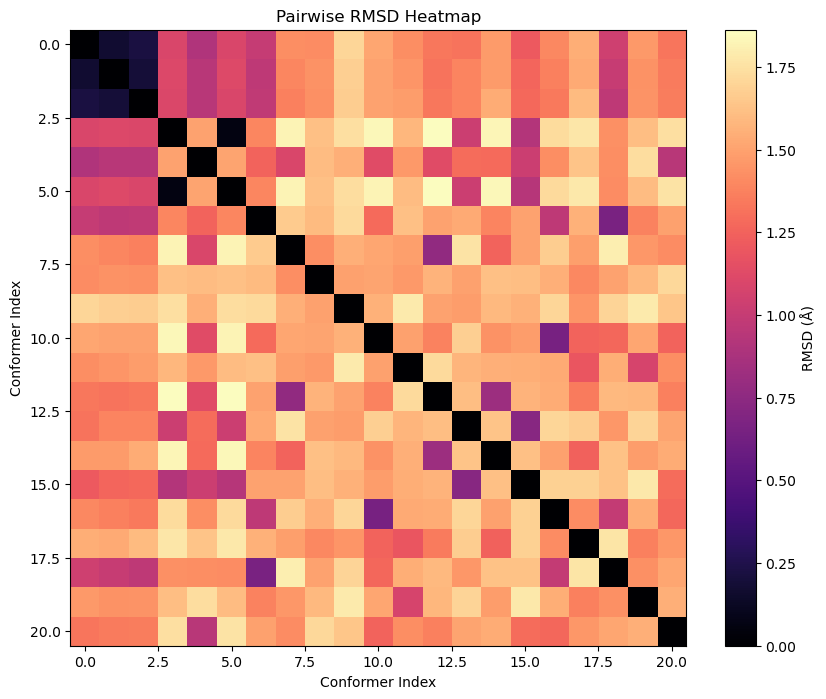

In [6]:
plt.figure(figsize=(10, 8))
plt.imshow(rmsd_matrix, cmap='magma', vmin=0, vmax=np.max(rmsd_matrix))
plt.colorbar(label="RMSD (Å)")

plt.xlabel("Conformer Index")
plt.ylabel("Conformer Index")

plt.title("Pairwise RMSD Heatmap")

plt.show()

8. Identify unique conformers (based on determined rmsd threshold)

In [7]:
basins = []

for conf in conformer_list_filtered:
    assigned = False
    conf_id = conf["id"]

    for basin in basins:
        rep_id = basin["representative"]["id"]

        rmsd = rdMolAlign.GetBestRMS(
            mol,
            mol,
            prbId=conf_id,
            refId=rep_id
        )

        if rmsd < RMSD_THRESHOLD:
            basin["members"].append(conf)
            assigned = True
            break

    if not assigned:
        basins.append({
            "representative": conf,
            "members": [conf]
        })

for basin_id, basin in enumerate(basins, start=1):
    basin["id"] = basin_id
    basin["size"] = len(basin["members"])
    basin["member_ids"] = [member["id"] for member in basin["members"]]
    basin["population"] = sum(member.get("population", 0.0) for member in basin["members"])
    basin["min_energy"] = min(member["energy"] for member in basin["members"])
    basin["representative_id"] = basin["representative"]["id"]

# unique conformers initialized to keep below working
unique_conformers = [basin["representative"] for basin in basins]

print(f"Number of basins: {len(basins)}")
print(f"Number of unique conformer representatives: {len(unique_conformers)}")

print("\nBasins:")
for basin in basins:
    print(
        f"Basin {basin['id']} | "
        f"Representative: {basin['representative_id']} | "
        f"Size: {basin['size']} | "
        f"Population: {basin['population'] * 100:.2f}% | "
        f"Members: {basin['member_ids']}"
    )

# Previous deduplication approach 
# unique_conformers = []
#
# for conf in conformer_list_filtered:
#     is_duplicate = False
#     for unique_conf in unique_conformers:
#         id1 = conf["id"]
#         id2 = unique_conf["id"]
#
#         rmsd = rdMolAlign.GetBestRMS(
#             mol,
#             mol,
#             prbId=id1,
#             refId=id2
#         )
#
#         if rmsd < RMSD_THRESHOLD:
#             is_duplicate = True
#             break
#     if not is_duplicate:
#         unique_conformers.append(conf)
# print(f"Number of unique conformers: {len(unique_conformers)}")
#
# print("\n\n", "Unique conformers (ID, Energy in kcal/mol):")
# for conf in unique_conformers:
#     print(conf["id"], conf["energy"])


Number of basins: 15
Number of unique conformer representatives: 15

Basins:
Basin 1 | Representative: 20 | Size: 3 | Population: 29.63% | Members: [20, 1, 10]
Basin 2 | Representative: 22 | Size: 2 | Population: 14.73% | Members: [22, 17]
Basin 3 | Representative: 13 | Size: 1 | Population: 7.22% | Members: [13]
Basin 4 | Representative: 3 | Size: 2 | Population: 7.47% | Members: [3, 19]
Basin 5 | Representative: 5 | Size: 1 | Population: 5.52% | Members: [5]
Basin 6 | Representative: 21 | Size: 1 | Population: 4.92% | Members: [21]
Basin 7 | Representative: 9 | Size: 1 | Population: 4.27% | Members: [9]
Basin 8 | Representative: 16 | Size: 2 | Population: 5.93% | Members: [16, 23]
Basin 9 | Representative: 7 | Size: 1 | Population: 3.31% | Members: [7]
Basin 10 | Representative: 11 | Size: 1 | Population: 3.13% | Members: [11]
Basin 11 | Representative: 18 | Size: 2 | Population: 5.25% | Members: [18, 12]
Basin 12 | Representative: 4 | Size: 1 | Population: 2.65% | Members: [4]
Basin

Basin heatmap

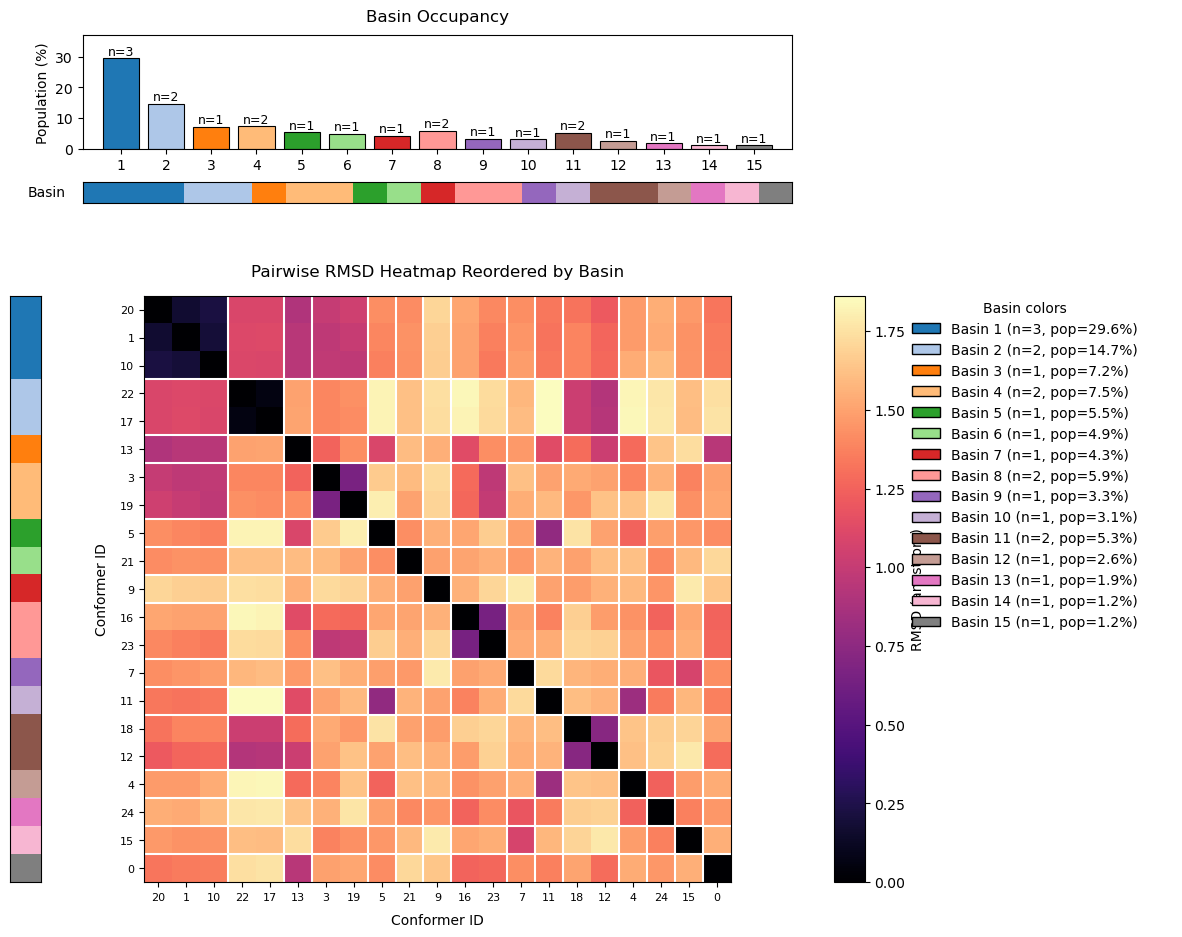

In [8]:
from matplotlib.patches import Patch

if not basins:
    raise ValueError("No basins found. Run the basin clustering cell first.")

conf_id_to_matrix_index = {
    conf["id"]: idx
    for idx, conf in enumerate(conformer_list_filtered)
}

ordered_conf_ids = []
ordered_basin_ids = []
ordered_indices = []

for basin in basins:
    basin_id = basin["id"]

    for member in basin["members"]:
        conf_id = member["id"]

        if conf_id not in conf_id_to_matrix_index:
            continue

        ordered_conf_ids.append(conf_id)
        ordered_basin_ids.append(basin_id)
        ordered_indices.append(conf_id_to_matrix_index[conf_id])

if not ordered_indices:
    raise ValueError("No basin members matched conformers in rmsd_matrix.")

rmsd_matrix_by_basin = rmsd_matrix[np.ix_(ordered_indices, ordered_indices)]

base_cmap = plt.get_cmap("tab20")
basin_colors = {
    basin["id"]: base_cmap(i % base_cmap.N)
    for i, basin in enumerate(basins)
}

ordered_colors = np.array([
    basin_colors[basin_id]
    for basin_id in ordered_basin_ids
])

basin_ids = [basin["id"] for basin in basins]
basin_populations = [basin["population"] * 100 for basin in basins]
basin_sizes = [basin["size"] for basin in basins]
basin_member_counts_in_order = [
    sum(1 for basin_id in ordered_basin_ids if basin_id == basin["id"])
    for basin in basins
]
basin_boundaries = np.cumsum(basin_member_counts_in_order)[:-1]

fig = plt.figure(figsize=(15, 11))
grid = fig.add_gridspec(
    nrows=4,
    ncols=4,
    width_ratios=[0.35, 8, 0.35, 3.0],
    height_ratios=[1.55, 0.28, 0.35, 8],
    hspace=0.18,
    wspace=0.16
)

ax_occupancy = fig.add_subplot(grid[0, 1])
ax_top_colors = fig.add_subplot(grid[1, 1])
ax_side_colors = fig.add_subplot(grid[3, 0])
ax_heatmap = fig.add_subplot(grid[3, 1])
ax_colorbar = fig.add_subplot(grid[3, 2])
ax_legend = fig.add_subplot(grid[3, 3])
ax_legend.axis("off")

bar_colors = [basin_colors[basin_id] for basin_id in basin_ids]
bar_positions = np.arange(len(basin_ids))
ax_occupancy.bar(
    bar_positions,
    basin_populations,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8
)

for x_pos, population, size in zip(bar_positions, basin_populations, basin_sizes):
    ax_occupancy.text(
        x_pos,
        population,
        f"n={size}",
        ha="center",
        va="bottom",
        fontsize=9
    )

occupancy_ymax = max(max(basin_populations) * 1.25, 1) if basin_populations else 1
ax_occupancy.set_ylim(0, occupancy_ymax)
ax_occupancy.set_title("Basin Occupancy", pad=10)
ax_occupancy.set_xlabel("Basin", labelpad=6)
ax_occupancy.set_ylabel("Population (%)")
ax_occupancy.set_xticks(bar_positions)
ax_occupancy.set_xticklabels([str(basin_id) for basin_id in basin_ids], rotation=0, ha="center")
ax_occupancy.margins(x=0.03)

ax_top_colors.imshow(ordered_colors[np.newaxis, :, :], aspect="auto")
ax_top_colors.set_xticks([])
ax_top_colors.set_yticks([])
ax_top_colors.set_ylabel("Basin", rotation=0, ha="right", va="center", labelpad=12)

ax_side_colors.imshow(ordered_colors[:, np.newaxis, :], aspect="auto")
ax_side_colors.set_xticks([])
ax_side_colors.set_yticks([])

rmsd_vmax = max(float(np.max(rmsd_matrix_by_basin)), 1e-12)
heatmap = ax_heatmap.imshow(
    rmsd_matrix_by_basin,
    cmap="magma",
    vmin=0,
    vmax=rmsd_vmax
)

for boundary in basin_boundaries:
    ax_heatmap.axhline(boundary - 0.5, color="white", linewidth=1.5)
    ax_heatmap.axvline(boundary - 0.5, color="white", linewidth=1.5)

if len(ordered_conf_ids) <= 24:
    tick_positions = np.arange(len(ordered_conf_ids))
    ax_heatmap.set_xticks(tick_positions)
    ax_heatmap.set_yticks(tick_positions)
    ax_heatmap.set_xticklabels(ordered_conf_ids, rotation=0, ha="center", fontsize=8)
    ax_heatmap.set_yticklabels(ordered_conf_ids, fontsize=8)
elif len(ordered_conf_ids) <= 48:
    tick_positions = np.arange(0, len(ordered_conf_ids), 2)
    ax_heatmap.set_xticks(tick_positions)
    ax_heatmap.set_yticks(tick_positions)
    ax_heatmap.set_xticklabels(
        [ordered_conf_ids[i] for i in tick_positions],
        rotation=0,
        ha="center",
        fontsize=7
    )
    ax_heatmap.set_yticklabels([ordered_conf_ids[i] for i in tick_positions], fontsize=7)
else:
    ax_heatmap.set_xticks([])
    ax_heatmap.set_yticks([])

ax_heatmap.set_title("Pairwise RMSD Heatmap Reordered by Basin", pad=14)
ax_heatmap.set_xlabel("Conformer ID", labelpad=8)
ax_heatmap.set_ylabel("Conformer ID", labelpad=8)

legend_handles = [
    Patch(
        facecolor=basin_colors[basin["id"]],
        edgecolor="black",
        label=(
            f"Basin {basin['id']} "
            f"(n={basin['size']}, pop={basin['population'] * 100:.1f}%)"
        )
    )
    for basin in basins
]

ax_legend.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=False,
    title="Basin colors",
    borderaxespad=0
)

fig.colorbar(heatmap, cax=ax_colorbar, label="RMSD (angstrom)")
plt.show()


9. Compute entropy + population analysis
- Shannon entropy calculation

$S = -\sum_{i} p_i \ln p_i$

In [9]:
populations = np.array([conf["population"] for conf in unique_conformers])
for conf in unique_conformers:
    conf["entropy"] = -np.sum(populations * np.log(populations + 1e-12)) # makes sure log(0) is avoided

print("conformational entropies: ")
for conf in unique_conformers:
    print(f"id: {conf['id']}, entropy: {conf['entropy']:.2f} kcal/mol*K")

conformational entropies: 
id: 20, entropy: 1.98 kcal/mol*K
id: 22, entropy: 1.98 kcal/mol*K
id: 13, entropy: 1.98 kcal/mol*K
id: 3, entropy: 1.98 kcal/mol*K
id: 5, entropy: 1.98 kcal/mol*K
id: 21, entropy: 1.98 kcal/mol*K
id: 9, entropy: 1.98 kcal/mol*K
id: 16, entropy: 1.98 kcal/mol*K
id: 7, entropy: 1.98 kcal/mol*K
id: 11, entropy: 1.98 kcal/mol*K
id: 18, entropy: 1.98 kcal/mol*K
id: 4, entropy: 1.98 kcal/mol*K
id: 24, entropy: 1.98 kcal/mol*K
id: 15, entropy: 1.98 kcal/mol*K
id: 0, entropy: 1.98 kcal/mol*K


11. Torsional Analysis
- 4 atom rotations
- middle bond rotates
- dihedral angle
- ignore -H torsions

    1. identify important rotatable bonds
    2. compute torsion angles
    3. store
    4. analyze distributions across ensemble


Good torsions to analyze:
- backbone C-C...
- C-C-OH
- branching regions

Notation
- first 3 atoms, i j k
- second 3 atoms, j k l




Describing the torsion angle
- 

In [10]:
def find_heavy_atom_torsions(mol):
    torsions = {}

    for bond in mol.GetBonds():
        if bond.GetBondType() != Chem.BondType.SINGLE:
            continue

        if bond.IsInRing():
            continue

        atom_2 = bond.GetBeginAtom()
        atom_3 = bond.GetEndAtom()

        if atom_2.GetAtomicNum() == 1 or atom_3.GetAtomicNum() == 1:
            continue

        left_neighbors = [
            atom.GetIdx()
            for atom in atom_2.GetNeighbors()
            if atom.GetIdx() != atom_3.GetIdx() and atom.GetAtomicNum() > 1
        ]

        right_neighbors = [
            atom.GetIdx()
            for atom in atom_3.GetNeighbors()
            if atom.GetIdx() != atom_2.GetIdx() and atom.GetAtomicNum() > 1
        ]

        if not left_neighbors or not right_neighbors:
            continue

        atom_1 = left_neighbors[0]
        atom_4 = right_neighbors[0]

        name = f"torsion_{len(torsions) + 1}_{atom_1}_{atom_2.GetIdx()}_{atom_3.GetIdx()}_{atom_4}"
        torsions[name] = (atom_1, atom_2.GetIdx(), atom_3.GetIdx(), atom_4)

    return torsions


# manually override this later with chemically meaningful names:
# torsion_definitions = {
#     "backbone_1": (0, 1, 2, 3),
#     "backbone_2": (1, 2, 3, 4),
# }

if "torsion_definitions" not in globals() or not torsion_definitions:
    torsion_definitions = find_heavy_atom_torsions(mol)

torsion_data = []

for conf in unique_conformers:
    conf_id = conf["id"]
    conformer = conf.get("conformer", mol.GetConformer(conf_id))

    torsions = {}

    for name, atoms in torsion_definitions.items():
        angle = GetDihedralDeg(conformer, *atoms)
        torsions[name] = angle

    torsion_data.append({
        "id": conf_id,
        "energy": conf["energy"],
        "population": conf["population"],
        "torsions": torsions
    })

torsion_rows = []

for record in torsion_data:
    row = {
        "id": record["id"],
        "energy": record["energy"],
        "population": record["population"],
    }
    row.update(record["torsions"])
    torsion_rows.append(row)

torsion_df = pd.DataFrame(torsion_rows)

print("Torsion definitions:")
for name, atoms in torsion_definitions.items():
    print(f"{name}: {atoms}")

torsion_df

Torsion definitions:
torsion_1_0_1_2_3: (0, 1, 2, 3)
torsion_2_1_2_3_4: (1, 2, 3, 4)
torsion_3_2_3_5_6: (2, 3, 5, 6)
torsion_4_3_5_6_7: (3, 5, 6, 7)
torsion_5_5_6_7_8: (5, 6, 7, 8)
torsion_6_6_7_8_9: (6, 7, 8, 9)


,id,energy,population,torsion_1_0_1_2_3,torsion_2_1_2_3_4,torsion_3_2_3_5_6,torsion_4_3_5_6_7,torsion_5_5_6_7_8,torsion_6_6_7_8_9
0,20,-20987.134876,0.108782,178.920447,-12.635821,-179.548103,90.405530,177.202207,177.900565
1,22,-20986.953484,0.080093,170.513610,-21.394191,175.593599,103.886118,-65.766168,-170.418191
2,13,-20986.891864,0.072182,-174.517637,79.812186,175.228466,78.951387,175.789457,172.234887
3,3,-20986.804936,0.062332,-177.126695,-123.572639,179.010289,85.554296,-174.076005,-178.062704
4,5,-20986.733466,0.055249,55.772003,63.519332,176.875637,83.143496,169.899935,171.789730
5,21,-20986.664314,0.049162,-66.589459,-22.071525,179.066350,88.960242,179.966218,-67.665517
6,9,-20986.581507,0.042750,-76.419076,-17.574129,177.532552,-156.653127,70.089861,179.073949
7,16,-20986.535815,0.039577,-173.353589,97.183507,178.218987,90.502890,-177.283290,-68.015088
8,7,-20986.429219,0.033060,-71.918249,74.745963,176.380054,78.550615,177.458370,62.179579
9,11,-20986.397025,0.031312,65.932496,12.082192,178.482300,166.786502,175.361481,179.042708


###Torsion histogram
- x: angle
- y: occurences

* maps important torsions

broader peaks --> more rotational freedom --> more flexibility

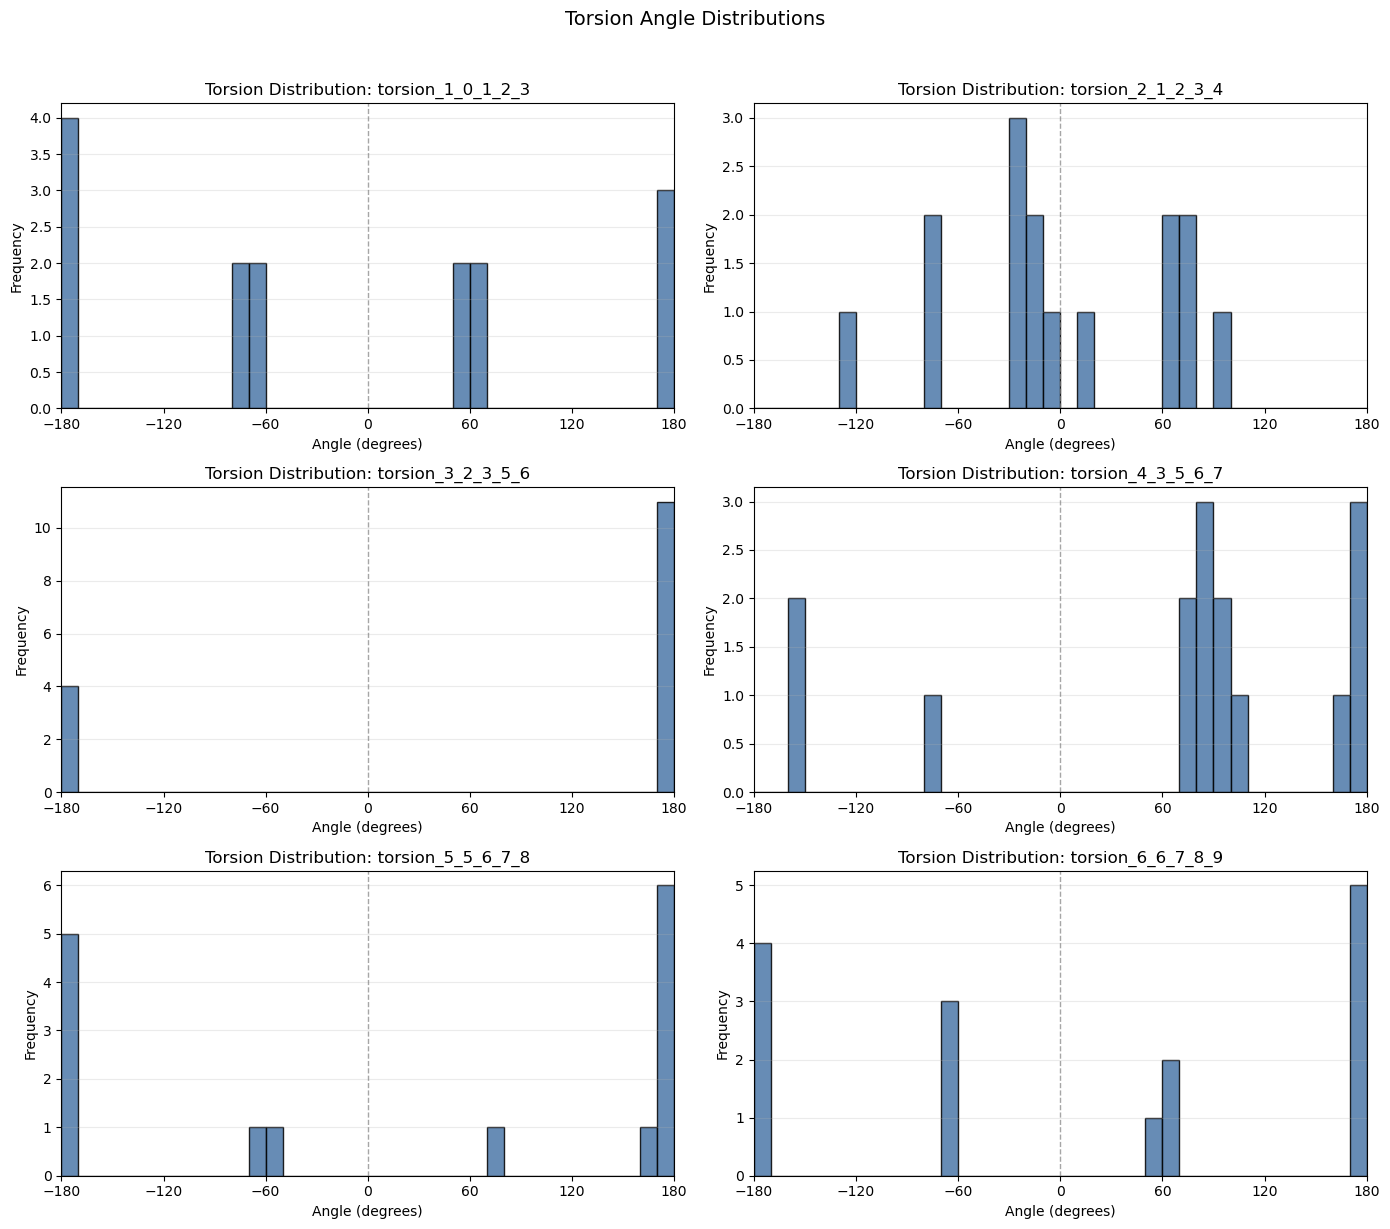

In [11]:
# Torsion histogram
if "torsion_df" not in globals():
    if "torsion_data" not in globals():
        raise ValueError("Run the torsion analysis cell first to create torsion_data or torsion_df.")

    torsion_rows = []

    for record in torsion_data:
        row = {
            "id": record["id"],
            "energy": record["energy"],
            "population": record["population"],
        }
        row.update(record["torsions"])
        torsion_rows.append(row)

    torsion_df = pd.DataFrame(torsion_rows)

metadata_columns = {"id", "energy", "population"}
torsion_columns = [
    column
    for column in torsion_df.columns
    if column not in metadata_columns
]

if not torsion_columns:
    raise ValueError("No torsion angle columns found in torsion_df.")

bins = np.linspace(-180, 180, 37)
n_cols = min(2, len(torsion_columns))
n_rows = math.ceil(len(torsion_columns) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7 * n_cols, 4 * n_rows),
    squeeze=False
)

for ax, torsion_name in zip(axes.flat, torsion_columns):
    angles = torsion_df[torsion_name].dropna().astype(float)

    ax.hist(angles, bins=bins, color="#4C78A8", edgecolor="black", alpha=0.85)
    ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)

    ax.set_title(f"Torsion Distribution: {torsion_name}")
    ax.set_xlabel("Angle (degrees)")
    ax.set_ylabel("Frequency")
    ax.set_xlim(-180, 180)
    ax.set_xticks(np.arange(-180, 181, 60))
    ax.grid(axis="y", alpha=0.25)

for ax in axes.flat[len(torsion_columns):]:
    ax.axis("off")

fig.suptitle("Torsion Angle Distributions", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

In [12]:

'''
# generate ase Atoms object for more optimal conformer and view
genpositions = results[0]['conformer'].GetPositions()
gensymbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
genatom = atoms.Atoms(symbols=gensymbols, positions=genpositions)
view(genatom)
'''

"\n# generate ase Atoms object for more optimal conformer and view\ngenpositions = results[0]['conformer'].GetPositions()\ngensymbols = [atom.GetSymbol() for atom in mol.GetAtoms()]\ngenatom = atoms.Atoms(symbols=gensymbols, positions=genpositions)\nview(genatom)\n"